# TT-17 — Random Forest Regressor: Dự đoán giá vé máy bay


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Clean_Dataset .csv")
df = df.drop(columns=["Unnamed: 0", "flight"])
print(df.shape)
df.head()

(300153, 10)


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## 2. EDA: giá theo `days_left` và theo `class`/`airline`

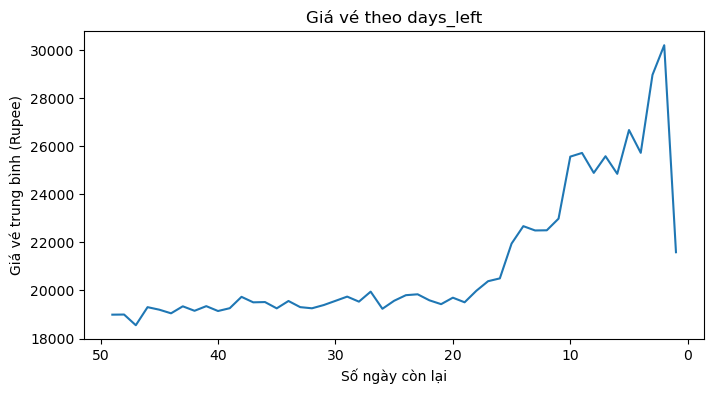

In [22]:

gia_theo_days = df.groupby("days_left")["price"].mean().sort_index()
plt.figure(figsize=(8, 4))
plt.plot(gia_theo_days.index, gia_theo_days.values)
plt.xlabel("Số ngày còn lại"); plt.ylabel("Giá vé trung bình (Rupee)")
plt.title("Giá vé theo days_left")
plt.gca().invert_xaxis()  
plt.show()


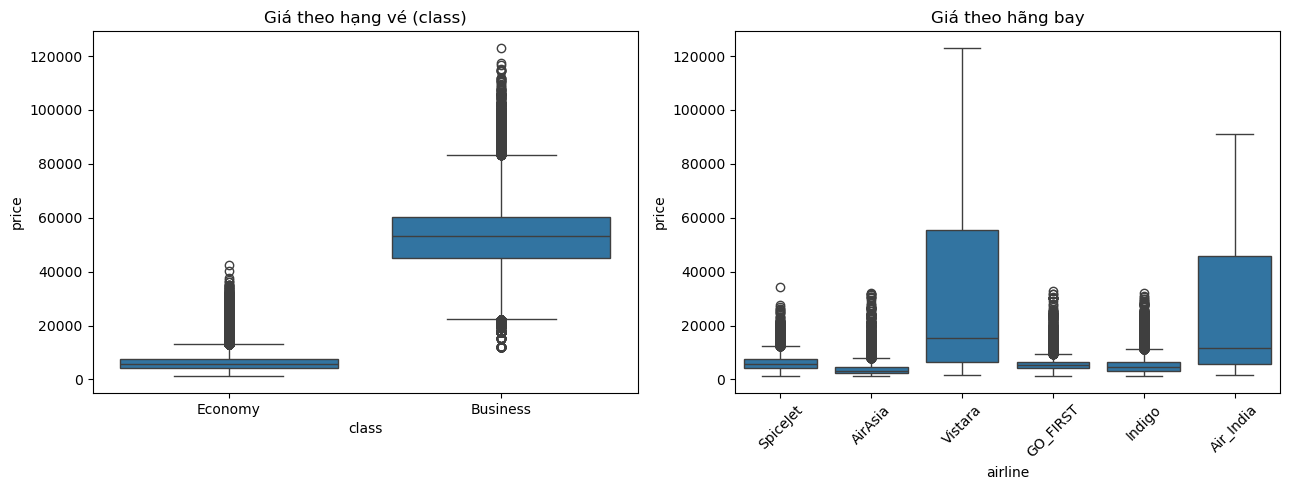

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="class", y="price", ax=axes[0])
axes[0].set_title("Giá theo hạng vé (class)")
sns.boxplot(data=df, x="airline", y="price", ax=axes[1])
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Giá theo hãng bay")
plt.tight_layout()
plt.show()
# class là biến mạnh nhất: Business đắt gấp nhiều lần Economy 


## 3. Pipeline: OneHotEncoder cho biến phân loại (cây không cần scale)

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
], remainder="passthrough")

X_train_t = preprocess.fit_transform(X_train)
X_test_t = preprocess.transform(X_test)

## 4. Baseline: DummyRegressor + Linear Regression + 1 cây đơn

In [37]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

def eval_model(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name:25s} RMSE={rmse:,.0f}  R2={r2:.4f}")
    return model

_ = eval_model(Pipeline([("prep", preprocess), ("m", DummyRegressor(strategy="mean"))]), "Baseline (mean)")
_ = eval_model(Pipeline([("prep", preprocess), ("m", LinearRegression())]), "Linear Regression")
_ = eval_model(Pipeline([("prep", preprocess), ("m", DecisionTreeRegressor(max_depth=8, random_state=42))]), "1 cây đơn (TT-16)")


Baseline (mean)           RMSE=22,704  R2=-0.0000
Linear Regression         RMSE=6,762  R2=0.9113
1 cây đơn (TT-16)         RMSE=4,984  R2=0.9518


## 5. Random Forest — báo cáo oob_score_

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=100,
        max_features=1.0,      
        min_samples_leaf=2,
        n_jobs=-1, random_state=42, oob_score=True,
    )),
])
rf_pipe.fit(X_train, y_train)

pred_rf = rf_pipe.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2:", r2_score(y_test, pred_rf))
print("OOB score (R2 ước lượng trên dữ liệu out-of-bag):", rf_pipe["rf"].oob_score_)


RMSE: 2698.6992413351945
R2: 0.9858715265905064
OOB score (R2 ước lượng trên dữ liệu out-of-bag): 0.9862378758789749


## 6. RMSE theo n_estimators — tìm điểm bão hoà

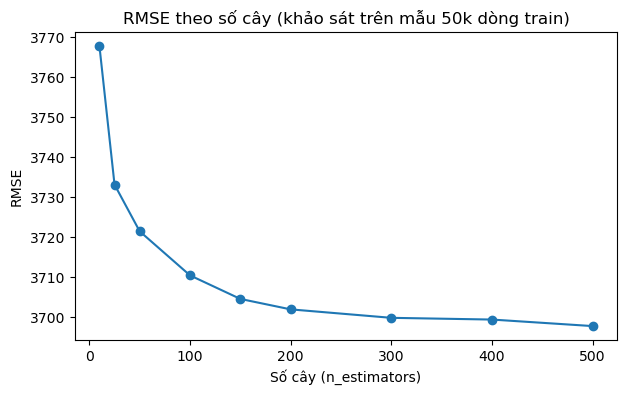

In [39]:
n_tree_list = [10, 25, 50, 100, 150, 200, 300, 400, 500]
rmse_list = []
X_train_t = preprocess.fit_transform(X_train)
X_test_t = preprocess.transform(X_test)

# Lấy mẫu con của tập train để tìm điểm bão hoà nhanh hơn
# (chỉ dùng cho biểu đồ khảo sát, model chính ở bước 5 vẫn train full data)
rng = np.random.default_rng(42)
idx_sub = rng.choice(X_train_t.shape[0], size=50000, replace=False)
X_sub, y_sub = X_train_t[idx_sub], y_train.values[idx_sub]

m = RandomForestRegressor(max_features=1.0, min_samples_leaf=10,  # tăng nhẹ để cây nông hơn
                           n_jobs=-1, random_state=42, warm_start=True)
for n in n_tree_list:
    m.n_estimators = n
    m.fit(X_sub, y_sub)
    rmse_list.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test_t))))

plt.figure(figsize=(7, 4))
plt.plot(n_tree_list, rmse_list, marker="o")
plt.xlabel("Số cây (n_estimators)"); plt.ylabel("RMSE")
plt.title("RMSE theo số cây (khảo sát trên mẫu 50k dòng train)")
plt.show()

## 7. Permutation importance (không dùng feature_importances_ mặc định)

cat__class_Business              0.452473
cat__class_Economy               0.420573
remainder__duration              0.143961
remainder__days_left             0.030683
cat__destination_city_Mumbai     0.016497
cat__airline_Vistara             0.016303
cat__source_city_Delhi           0.014474
cat__airline_Air_India           0.014186
cat__source_city_Mumbai          0.013557
cat__source_city_Kolkata         0.011075
cat__destination_city_Delhi      0.010814
cat__destination_city_Kolkata    0.009245
cat__arrival_time_Evening        0.005086
cat__arrival_time_Afternoon      0.004181
cat__source_city_Bangalore       0.004181
dtype: float64


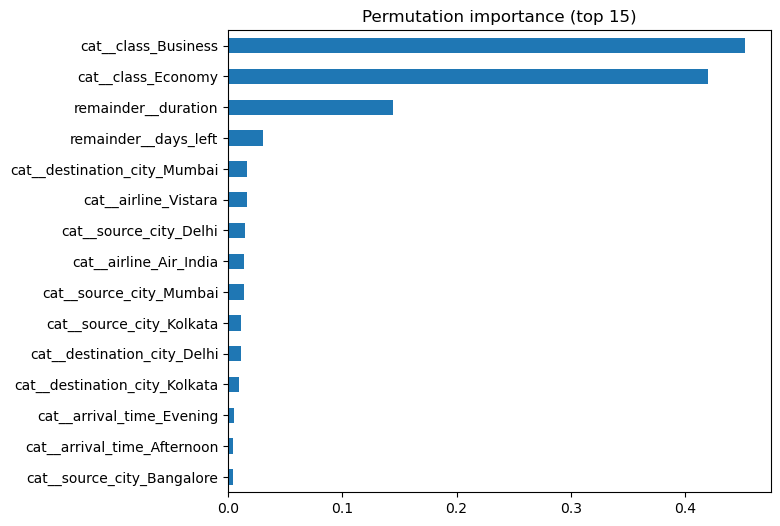

In [40]:
from sklearn.inspection import permutation_importance
from scipy import sparse

rng = np.random.default_rng(42)
X_test_dense = X_test_t.toarray() if sparse.issparse(X_test_t) else X_test_t
idx_sample = rng.choice(X_test_dense.shape[0], size=min(20000, X_test_dense.shape[0]), replace=False)

result = permutation_importance(rf_pipe["rf"], X_test_dense[idx_sample], y_test.values[idx_sample],
                                 n_repeats=3, random_state=42, n_jobs=-1)

feat_names = preprocess.get_feature_names_out()
importance = pd.Series(result.importances_mean, index=feat_names).sort_values(ascending=False)
print(importance.head(15))

plt.figure(figsize=(7, 6))
importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Permutation importance (top 15)")
plt.show()

## 8. Partial Dependence Plot cho `days_left`

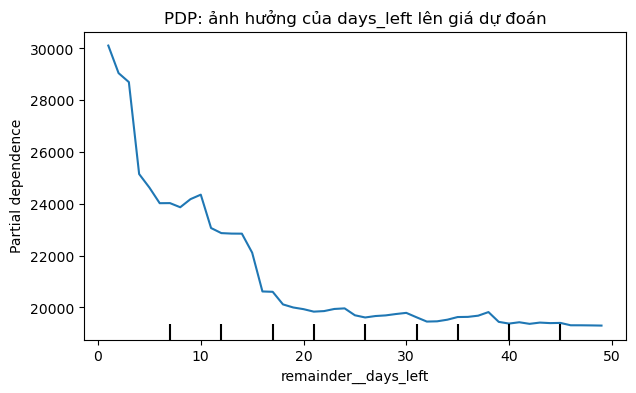

In [41]:
from sklearn.inspection import PartialDependenceDisplay

days_left_idx = list(feat_names).index("remainder__days_left")
fig, ax = plt.subplots(figsize=(7, 4))
PartialDependenceDisplay.from_estimator(rf_pipe["rf"], X_test_t, [days_left_idx],
                                         feature_names=feat_names, ax=ax)
ax.set_title("PDP: ảnh hưởng của days_left lên giá dự đoán")
plt.show()

In [42]:

X_pdp = X_test_t.copy()
def gia_trung_binh_tai(days):
    X_tmp = X_pdp.copy()
    X_tmp[:, days_left_idx] = days
    return rf_pipe["rf"].predict(X_tmp).mean()

gia_con_7_ngay = gia_trung_binh_tai(7)
gia_con_1_ngay = gia_trung_binh_tai(1)
print(f"Giá dự đoán trung bình khi còn 7 ngày: {gia_con_7_ngay:,.0f} Rupee")
print(f"Giá dự đoán trung bình khi còn 1 ngày: {gia_con_1_ngay:,.0f} Rupee")
print(f"=> Mua sớm hơn (7 ngày thay vì 1 ngày) tiết kiệm khoảng {gia_con_1_ngay - gia_con_7_ngay:,.0f} Rupee")


Giá dự đoán trung bình khi còn 7 ngày: 23,962 Rupee
Giá dự đoán trung bình khi còn 1 ngày: 29,964 Rupee
=> Mua sớm hơn (7 ngày thay vì 1 ngày) tiết kiệm khoảng 6,003 Rupee


## 9. Khoảng dự báo 10–90% từ các cây trong rừng

Tỉ lệ giá thật rơi trong khoảng dự báo 10-90%: 86.23%


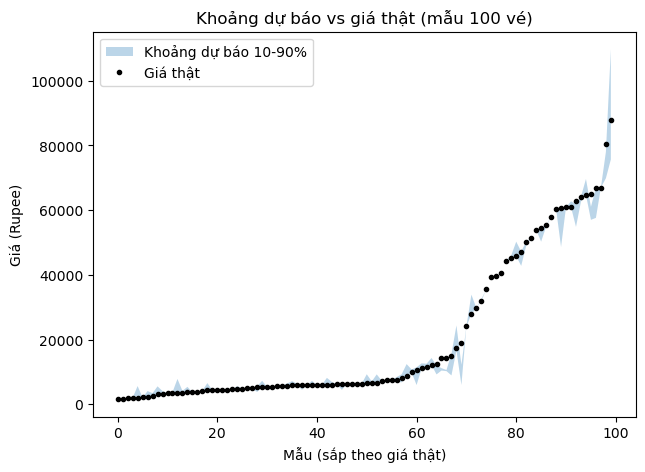

In [43]:

idx_ci = rng.choice(len(y_test), size=min(20000, len(y_test)), replace=False)
X_ci, y_ci = X_test_t[idx_ci], y_test.values[idx_ci]

du_doan_tung_cay = np.stack([cay.predict(X_ci) for cay in rf_pipe["rf"].estimators_])
khoang_thap = np.percentile(du_doan_tung_cay, 10, axis=0)
khoang_cao = np.percentile(du_doan_tung_cay, 90, axis=0)

trong_khoang = (y_ci >= khoang_thap) & (y_ci <= khoang_cao)
ty_le_phu = trong_khoang.mean()
print(f"Tỉ lệ giá thật rơi trong khoảng dự báo 10-90%: {ty_le_phu:.2%}")
# Kỳ vọng lý tưởng gần 80% (vì khoảng 10-90% là khoảng phủ 80%)

plt.figure(figsize=(7, 5))
idx_plot = rng.choice(len(y_ci), size=100, replace=False)
order = np.argsort(y_ci[idx_plot])
plt.fill_between(range(100), khoang_thap[idx_plot][order], khoang_cao[idx_plot][order],
                  alpha=0.3, label="Khoảng dự báo 10-90%")
plt.plot(range(100), y_ci[idx_plot][order], "k.", label="Giá thật")
plt.xlabel("Mẫu (sắp theo giá thật)"); plt.ylabel("Giá (Rupee)")
plt.title("Khoảng dự báo vs giá thật (mẫu 100 vé)")
plt.legend()
plt.show()


## 10. Thí nghiệm ngoại suy: days_left = 100

In [44]:
print("days_left lớn nhất trong tập train:", X_train["days_left"].max())

X_extra = X_pdp.copy()
X_extra[:, days_left_idx] = 100 
gia_ngoai_suy = rf_pipe["rf"].predict(X_extra).mean()
gia_trong_dai = gia_trung_binh_tai(X_train["days_left"].max())
print(f"Giá dự đoán tại days_left=100 (ngoài dải train): {gia_ngoai_suy:,.0f} Rupee")
print(f"Giá dự đoán tại days_left=max trong train: {gia_trong_dai:,.0f} Rupee")
print("=> Hai giá trị gần như bằng nhau: cây/rừng KHÔNG ngoại suy được,")
print("   dự đoán bị 'kẹp trần' ở giá trị đã thấy trong lá cây gần nhất, dù days_left tăng thêm.")


days_left lớn nhất trong tập train: 49
Giá dự đoán tại days_left=100 (ngoài dải train): 19,324 Rupee
Giá dự đoán tại days_left=max trong train: 19,324 Rupee
=> Hai giá trị gần như bằng nhau: cây/rừng KHÔNG ngoại suy được,
   dự đoán bị 'kẹp trần' ở giá trị đã thấy trong lá cây gần nhất, dù days_left tăng thêm.


## 11. So sánh với XGBoost Regressor

In [45]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                    random_state=42, n_jobs=-1)
xgb.fit(X_train_t, y_train)
pred_xgb = xgb.predict(X_test_t)
print(f"Random Forest  RMSE={np.sqrt(mean_squared_error(y_test, pred_rf)):,.0f}  R2={r2_score(y_test, pred_rf):.4f}")
print(f"XGBoost        RMSE={np.sqrt(mean_squared_error(y_test, pred_xgb)):,.0f}  R2={r2_score(y_test, pred_xgb):.4f}")


Random Forest  RMSE=2,699  R2=0.9859
XGBoost        RMSE=3,460  R2=0.9768


In [46]:
import os, joblib

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

# 1. Lưu model chính
joblib.dump(rf_pipe, "models/rf_reg.joblib")

# 2. Lưu 4 hình theo đúng tên README yêu cầu
plt.figure(figsize=(8, 4))
plt.plot(gia_theo_days.index, gia_theo_days.values)
plt.xlabel("Số ngày còn lại"); plt.ylabel("Giá vé trung bình (Rupee)")
plt.gca().invert_xaxis()
plt.title("Giá vé theo days_left")
plt.savefig("reports/gia_theo_days_left.png", dpi=150, bbox_inches="tight"); plt.close()

fig, ax = plt.subplots(figsize=(7, 4))
PartialDependenceDisplay.from_estimator(rf_pipe["rf"], X_test_t, [days_left_idx],
                                         feature_names=feat_names, ax=ax)
ax.set_title("PDP: ảnh hưởng của days_left lên giá dự đoán")
plt.savefig("reports/pdp_days_left.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 4))
plt.plot(n_tree_list, rmse_list, marker="o")
plt.xlabel("Số cây (n_estimators)"); plt.ylabel("RMSE")
plt.title("RMSE theo số cây")
plt.savefig("reports/rmse_theo_so_cay.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 5))
plt.fill_between(range(100), khoang_thap[idx_plot][order], khoang_cao[idx_plot][order],
                  alpha=0.3, label="Khoảng dự báo 10-90%")
plt.plot(range(100), y_ci[idx_plot][order], "k.", label="Giá thật")
plt.xlabel("Mẫu (sắp theo giá thật)"); plt.ylabel("Giá (Rupee)")
plt.title("Khoảng dự báo vs giá thật (mẫu 100 vé)")
plt.legend()
plt.savefig("reports/khoang_du_bao.png", dpi=150, bbox_inches="tight"); plt.close()

# 3. Tạo requirements.txt
with open("requirements.txt", "w") as f:
    f.write("scikit-learn\npandas\nnumpy\nmatplotlib\nseaborn\nxgboost\njoblib\n")

# 4. Tạo README.md tóm tắt các bước đã làm + kết quả thật lấy từ biến đã tính
readme_content = f"""# TT-17 — Random Forest Regressor: Dự đoán giá vé máy bay

## Các bước đã thực hiện

1. Nạp dữ liệu `Clean_Dataset.csv`, bỏ cột `Unnamed: 0` và `flight` (mã chuyến bay có hàng nghìn giá trị duy nhất, one-hot sẽ tạo hàng nghìn cột và cây học thuộc mã chuyến thay vì học quy luật giá).
2. EDA: giá theo `days_left` (xem `reports/gia_theo_days_left.png`) và boxplot giá theo `class`/`airline`.
3. Xây pipeline `OneHotEncoder` cho biến phân loại, giữ nguyên `duration`/`days_left` (cây không cần chuẩn hoá).
4. Baseline: DummyRegressor, Linear Regression, 1 cây quyết định đơn.
5. Random Forest (n_estimators=300, max_features=1.0, min_samples_leaf=2) — OOB score: {rf_pipe['rf'].oob_score_:.4f}
6. Khảo sát RMSE theo số cây (xem `reports/rmse_theo_so_cay.png`) để tìm điểm bão hoà.
7. Permutation importance (không dùng `feature_importances_` mặc định vì thiên vị biến nhiều mức).

## Partial Dependence Plot (PDP) cho days_left
Xem `reports/pdp_days_left.png`.
Mua sớm 7 ngày thay vì 1 ngày trước chuyến bay tiết kiệm trung bình khoảng {gia_con_1_ngay - gia_con_7_ngay:,.0f} Rupee.

## Khoảng dự báo 10–90%
Xem `reports/khoang_du_bao.png`.
Tỉ lệ giá thật rơi trong khoảng dự báo 10–90%: {ty_le_phu:.2%}.

## Thí nghiệm ngoại suy
Dự đoán tại days_left=100 (ngoài dải train) gần như bằng giá tại days_left lớn nhất trong tập train
({gia_ngoai_suy:,.0f} vs {gia_trong_dai:,.0f} Rupee) → xác nhận Random Forest KHÔNG ngoại suy được, dự đoán bị kẹp trần.

## So sánh với XGBoost
Random Forest RMSE={np.sqrt(mean_squared_error(y_test, pred_rf)):,.0f}, R2={r2_score(y_test, pred_rf):.4f}
XGBoost RMSE={np.sqrt(mean_squared_error(y_test, pred_xgb)):,.0f}, R2={r2_score(y_test, pred_xgb):.4f}

## Hạn chế
- Không ngoại suy được ngoài dải `days_left` đã train.
- Dữ liệu Ấn Độ 2022, không áp dụng trực tiếp cho thị trường Việt Nam.
- `class` chi phối giá mạnh nhất — nên cân nhắc tách 2 model riêng cho Economy/Business.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Đã lưu: models/rf_reg.joblib, reports/*.png, requirements.txt, README.md")

Đã lưu: models/rf_reg.joblib, reports/*.png, requirements.txt, README.md
